In [3]:
from astroquery.utils.tap.core import TapPlus
import pandas as pd

In [5]:
def check_vizier_server():
    url = "http://tapvizier.u-strasbg.fr/TAPVizieR/tap"
    print(f"Pinging {url}...")
    
    try:
        # Initialize connection
        vizier_tap = TapPlus(url=url)
        
        # Run the lightest possible query (just 1 row)
        job = vizier_tap.launch_job("SELECT TOP 1 * FROM \"I/355/gaiadr3\"")
        results = job.get_results()
        
        print("✅ Server is UP and responding properly!")
        print(f"✅ Successfully retrieved {len(results)} row(s).")
        
    except Exception as e:
        print("❌ Server appears to be DOWN or unreachable.")
        print(f"Error details: {e}")

if __name__ == "__main__":
    check_vizier_server()

Pinging http://tapvizier.u-strasbg.fr/TAPVizieR/tap...
✅ Server is UP and responding properly!
✅ Successfully retrieved 1 row(s).


In [20]:
def fetch_gaia_data_example():
    url = "http://tapvizier.u-strasbg.fr/TAPVizieR/tap"
    print(f"Connecting to {url}...")
    
    try:
        # Initialize connection
        vizier_tap = TapPlus(url=url)
        
        # Run a query to retrieve actual data (e.g., coordinates, parallax, and photometry)
        query = """
        SELECT TOP 100 *
        FROM "I/355/gaiadr3"
        """
        
        print("Executing query...")
        job = vizier_tap.launch_job(query)
        results = job.get_results()
        
        # Convert the result to a Pandas DataFrame
        df = results.to_pandas()
        
        
    except Exception as e:
        print("❌ Failed to retrieve data.")
        print(f"Error details: {e}")

    return  df

In [21]:
df_data = fetch_gaia_data_example()

Connecting to http://tapvizier.u-strasbg.fr/TAPVizieR/tap...
Executing query...


In [24]:
df_data.head()

,DR3Name,RA_ICRS,DE_ICRS,SolID,Source,RandomI,e_RA_ICRS,e_DE_ICRS,Plx,e_Plx,...,RAVE6,dRAVE6,f_RAVE6,RAVE6oid,nRAVE6,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000
0,Gaia DR3 4043164156755449984,268.676232,-33.546332,1636148068921376768,4043164156755449984,1190811949,5.0247,3.7122,NaN,NaN,...,,NaN,<NA>,NaN,<NA>,268.676232,-33.546332,5.024652,3.712146,0.9629
1,Gaia DR3 4043164152429949952,268.675826,-33.546119,1636148068921376768,4043164152429949952,1785158676,9.2783,8.4307,NaN,NaN,...,,NaN,<NA>,NaN,<NA>,268.675826,-33.546119,9.278338,8.430698,0.9910
2,Gaia DR3 4043164152491574016,268.674862,-33.547551,1636148068921376768,4043164152491574016,88891208,0.8542,0.6883,-2.02,0.7707,...,,NaN,<NA>,NaN,<NA>,268.674915,-33.547523,16.882404,11.553898,0.4816
3,Gaia DR3 4043164156829592064,268.674595,-33.546649,1636148068921376768,4043164156829592064,1743226853,7.0622,5.5236,NaN,NaN,...,,NaN,<NA>,NaN,<NA>,268.674595,-33.546649,7.062194,5.523622,0.9619
4,Gaia DR3 4043164156829592192,268.674312,-33.546994,1636148068921376768,4043164156829592192,1779211511,1.5133,2.0488,NaN,NaN,...,,NaN,<NA>,NaN,<NA>,268.674312,-33.546994,1.513264,2.048801,-0.1691


In [87]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 1000
    source_id,
    ra,
    dec,
    parallax,
    phot_g_mean_mag,
    bp_rp,
    teff_gspphot
FROM gaiadr3.gaia_source
WHERE parallax IS NOT NULL 
AND teff_gspphot IS NOT NULL
AND parallax > 0
"""

job = Gaia.launch_job_async(query)
stars = job.get_results()
df = stars.to_pandas()

INFO: Query finished. [astroquery.utils.tap.core]


In [88]:
import numpy as np

In [89]:
df["lum"] = df["phot_g_mean_mag"] + 5 + 5 * np.log10(df["parallax"] / 1000)

In [90]:
df.head()

,source_id,ra,dec,parallax,phot_g_mean_mag,bp_rp,teff_gspphot,lum
0,137339104073474816,45.056377,35.315475,0.546173,18.933025,1.875917,3791.892334,7.619678
1,137339207152692096,45.034470,35.321446,1.255606,18.127110,1.944653,3781.597900,8.621377
2,137339585109847424,45.100563,35.351433,0.628047,17.767200,1.498516,4147.422852,6.757161
3,137339761203576448,45.080347,35.366569,1.118986,15.065464,1.249895,4835.756836,5.309587
4,137341135593105920,45.146628,35.384976,0.318278,17.708527,0.999245,5096.623535,5.222557


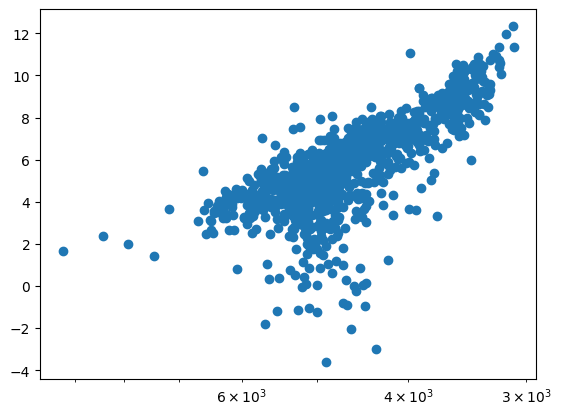

In [91]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

ax.xaxis.set_inverted(True)
ax.scatter(df["teff_gspphot"], df["lum"])
ax.set_xscale("log")
